In [3]:
%pip install -q yfinance

Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


# Task 2: Predict Future Stock Prices (Short-Term)

## Objective
Use historical stock data to predict the next day's closing price using machine learning models.

## Approach
1. Fetch historical stock data using yfinance
2. Engineer features from OHLCV data
3. Train Linear Regression and Random Forest models
4. Compare predictions with actual prices

In [1]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Step 1: Fetch Historical Stock Data

In [2]:
# Select a stock and fetch historical data
# Using Apple (AAPL) as an example
stock_symbol = 'AAPL'
print(f"Fetching historical data for {stock_symbol}...")

# Fetch data for the last 2 years
data = yf.download(stock_symbol, start='2023-01-01', end='2025-12-31', progress=False)

print(f"Data shape: {data.shape}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nData info:")
print(data.info())
print(f"\nBasic statistics:")
print(data.describe())

Fetching historical data for AAPL...
Data shape: (751, 5)

First few rows:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500
2023-01-04  124.365654  126.629356  123.105858  124.887288   89113600
2023-01-05  123.046814  125.753411  122.790923  125.123513   80962700
2023-01-06  127.574203  128.233627  122.918861  124.021187   87754700
2023-01-09  128.095825  131.304382  127.839934  128.410782   70790800

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751 entries, 2023-01-03 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   751 non-null    float64
 1   (High, AAPL)    751 non-null    float64
 2   (Low, AAPL)     751 non-null    float64
 3   

## Step 2: Data Exploration and Visualization

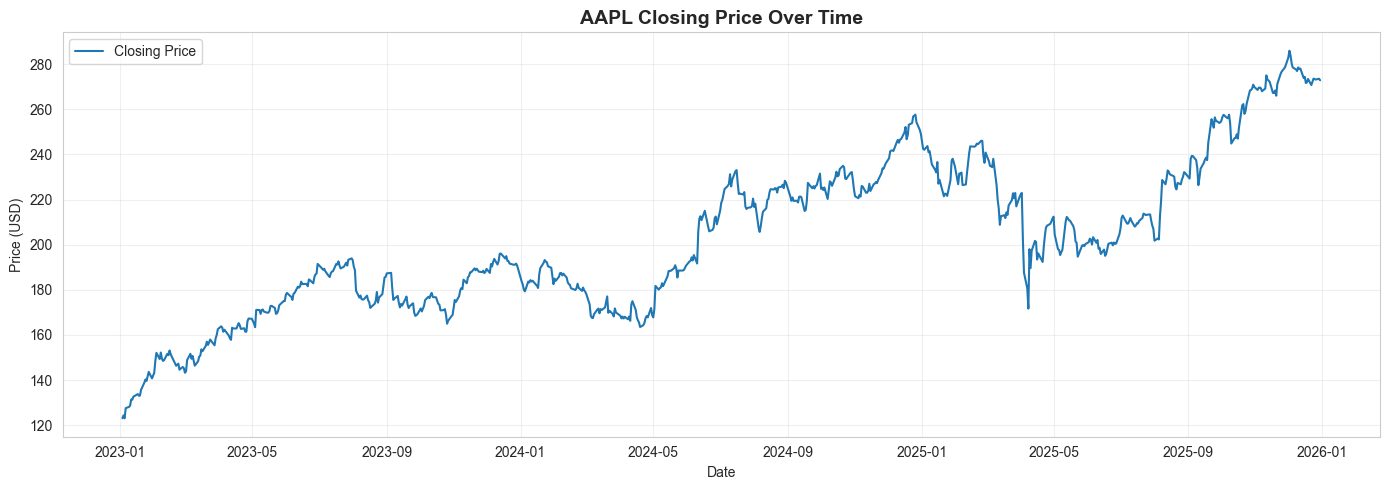

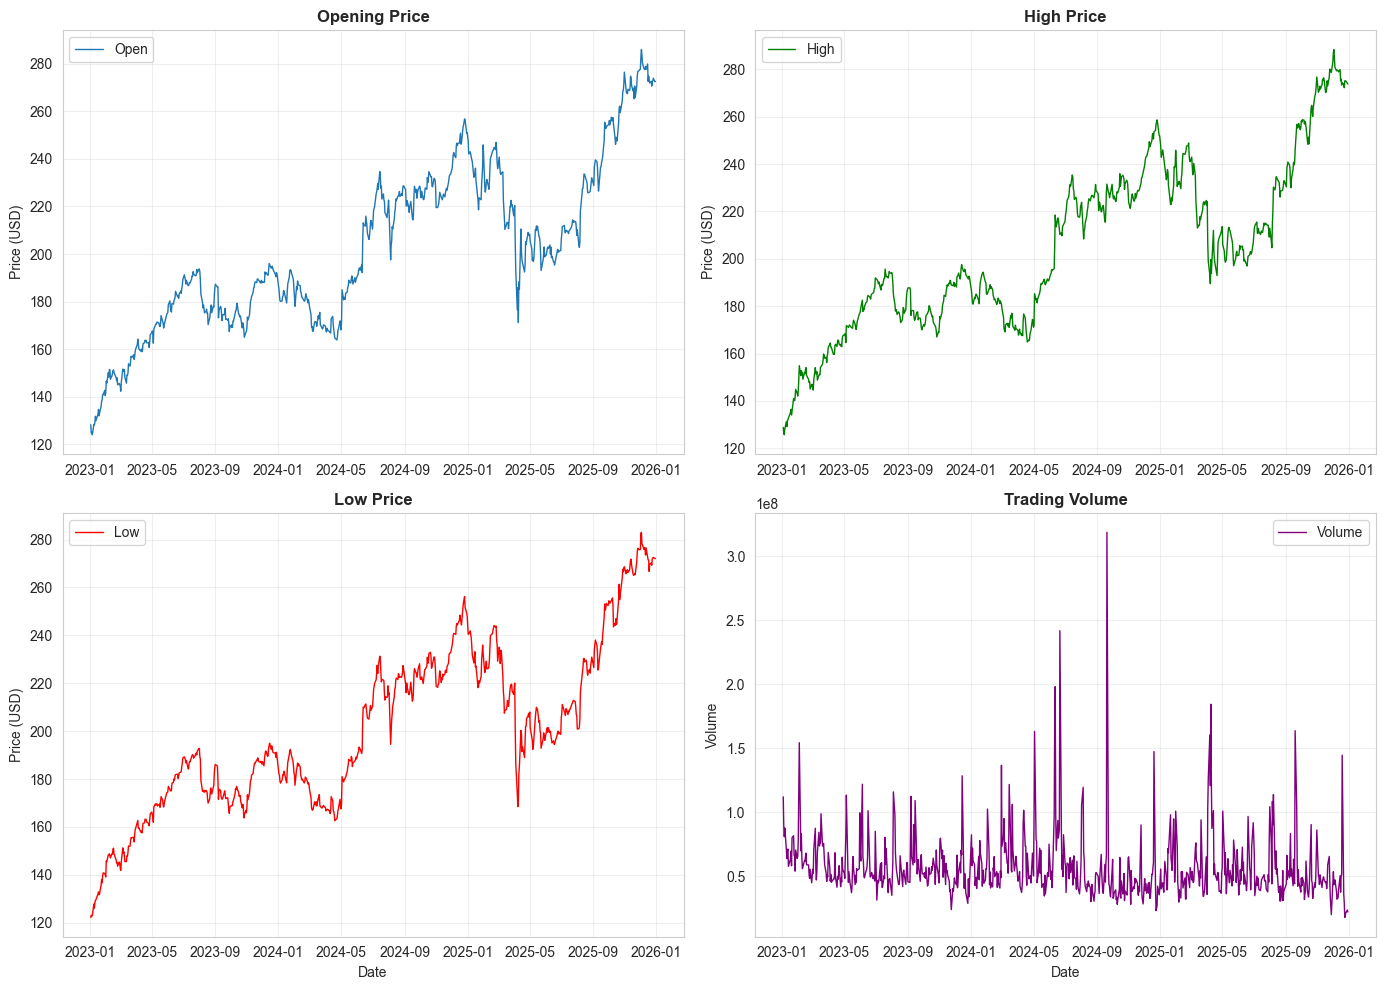

In [3]:
# Visualize the closing price over time
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['Close'], linewidth=1.5, label='Closing Price')
plt.title(f'{stock_symbol} Closing Price Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot all OHLC data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(data.index, data['Open'], label='Open', linewidth=1)
axes[0, 0].set_title('Opening Price', fontweight='bold')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(data.index, data['High'], label='High', linewidth=1, color='green')
axes[0, 1].set_title('High Price', fontweight='bold')
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(data.index, data['Low'], label='Low', linewidth=1, color='red')
axes[1, 0].set_title('Low Price', fontweight='bold')
axes[1, 0].set_ylabel('Price (USD)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(data.index, data['Volume'], label='Volume', linewidth=1, color='purple')
axes[1, 1].set_title('Trading Volume', fontweight='bold')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].set_xlabel('Date')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Feature Engineering

In [4]:
# Create a copy of the data for feature engineering
df = data.copy()

# Reset the index to have Date as a column
df.reset_index(inplace=True)
df.rename(columns={'Date': 'date'}, inplace=True)

# Create target variable: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)

# Drop the last row since it doesn't have a next day's closing price
df = df.dropna()

# Select features for the model
features = ['Open', 'High', 'Low', 'Volume']
X = df[features].values
y = df['Next_Close'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures statistics:")
print(df[features].describe())

# Check for any NaN or infinite values
print(f"\nNaN values in features: {df[features].isnull().sum().sum()}")
print(f"NaN values in target: {df['Next_Close'].isnull().sum()}")

Features shape: (750, 4)
Target shape: (750,)

Features statistics:
Price         Open        High         Low        Volume
Ticker        AAPL        AAPL        AAPL          AAPL
count   750.000000  750.000000  750.000000  7.500000e+02
mean    202.096195  204.166574  200.296078  5.692174e+07
std      34.255993   34.521815   33.901352  2.458986e+07
min     124.021187  125.753411  122.210234  1.791060e+07
25%     175.416818  177.437994  174.228553  4.369598e+07
50%     196.781710  199.425822  194.556777  5.121025e+07
75%     226.932030  228.888229  224.595448  6.349258e+07
max     285.932471  288.350192  283.035157  3.186799e+08

NaN values in features: 0
NaN values in target: 0


## Step 4: Train-Test Split

In [5]:
# Split the data into training and testing sets
# Using 80-20 split with shuffle=False to maintain time series order
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Train-Test ratio: {train_size}/{len(df)}")

Training set size: 600
Testing set size: 150
Train-Test ratio: 600/750


## Step 5: Train Linear Regression Model

In [6]:
# Initialize and train Linear Regression model
print("=" * 50)
print("LINEAR REGRESSION MODEL")
print("=" * 50)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluate the model
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print(f"\nLinear Regression Performance:")
print(f"Training R² Score: {train_r2_lr:.4f}")
print(f"Testing R² Score: {test_r2_lr:.4f}")
print(f"Training RMSE: ${train_rmse_lr:.2f}")
print(f"Testing RMSE: ${test_rmse_lr:.2f}")
print(f"Training MAE: ${train_mae_lr:.2f}")
print(f"Testing MAE: ${test_mae_lr:.2f}")

# Feature coefficients
print(f"\nFeature Coefficients:")
for feature, coef in zip(features, lr_model.coef_):
    print(f"  {feature}: {coef:.6f}")

LINEAR REGRESSION MODEL

Linear Regression Performance:
Training R² Score: 0.9862
Testing R² Score: 0.9849
Training RMSE: $3.40
Testing RMSE: $3.48
Training MAE: $2.37
Testing MAE: $2.46

Feature Coefficients:
  Open: -0.449573
  High: 0.790263
  Low: 0.646427
  Volume: -0.000000


## Step 6: Train Random Forest Model

In [7]:
# Initialize and train Random Forest model
print("\n" + "=" * 50)
print("RANDOM FOREST MODEL")
print("=" * 50)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate the model
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\nRandom Forest Performance:")
print(f"Training R² Score: {train_r2_rf:.4f}")
print(f"Testing R² Score: {test_r2_rf:.4f}")
print(f"Training RMSE: ${train_rmse_rf:.2f}")
print(f"Testing RMSE: ${test_rmse_rf:.2f}")
print(f"Training MAE: ${train_mae_rf:.2f}")
print(f"Testing MAE: ${test_mae_rf:.2f}")

# Feature importance
print(f"\nFeature Importance:")
for feature, importance in zip(features, rf_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")


RANDOM FOREST MODEL

Random Forest Performance:
Training R² Score: 0.9974
Testing R² Score: 0.8399
Training RMSE: $1.46
Testing RMSE: $11.36
Training MAE: $1.03
Testing MAE: $7.99

Feature Importance:
  Open: 0.0377
  High: 0.8294
  Low: 0.1291
  Volume: 0.0037


## Step 7: Model Comparison

In [8]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Metric': ['Train R²', 'Test R²', 'Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE'],
    'Linear Regression': [train_r2_lr, test_r2_lr, train_rmse_lr, test_rmse_lr, train_mae_lr, test_mae_lr],
    'Random Forest': [train_r2_rf, test_r2_rf, train_rmse_rf, test_rmse_rf, train_mae_rf, test_mae_rf]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Determine the best model
if test_r2_rf > test_r2_lr:
    print("\n✓ Random Forest model performs better on test data.")
    best_model = rf_model
    best_predictions = y_test_pred_rf
    best_name = "Random Forest"
else:
    print("\n✓ Linear Regression model performs better on test data.")
    best_model = lr_model
    best_predictions = y_test_pred_lr
    best_name = "Linear Regression"


MODEL COMPARISON SUMMARY
    Metric  Linear Regression  Random Forest
  Train R²           0.986161       0.997438
   Test R²           0.984944       0.839877
Train RMSE           3.397408       1.461802
 Test RMSE           3.483206      11.359234
 Train MAE           2.368168       1.029688
  Test MAE           2.464775       7.994882

✓ Linear Regression model performs better on test data.


## Step 8: Visualize Predictions vs Actual Prices

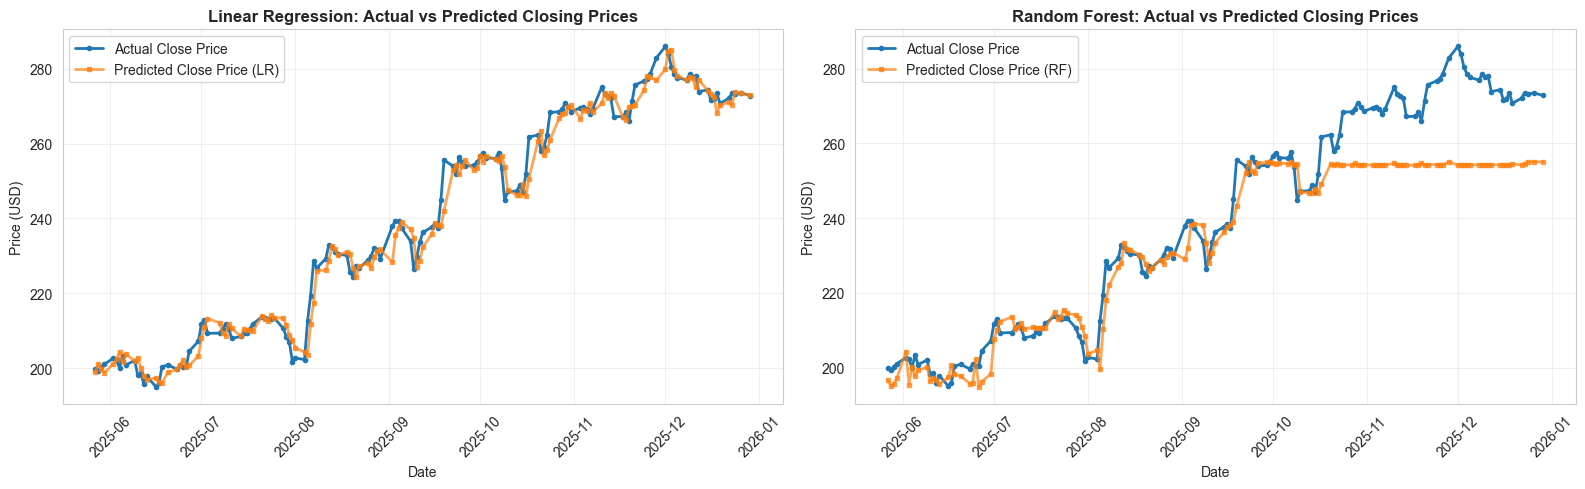

In [9]:
# Visualize Linear Regression predictions
test_dates = df['date'].iloc[train_size:].values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear Regression plot
axes[0].plot(test_dates, y_test, label='Actual Close Price', linewidth=2, marker='o', markersize=3)
axes[0].plot(test_dates, y_test_pred_lr, label='Predicted Close Price (LR)', linewidth=2, marker='s', markersize=3, alpha=0.7)
axes[0].set_title('Linear Regression: Actual vs Predicted Closing Prices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Random Forest plot
axes[1].plot(test_dates, y_test, label='Actual Close Price', linewidth=2, marker='o', markersize=3)
axes[1].plot(test_dates, y_test_pred_rf, label='Predicted Close Price (RF)', linewidth=2, marker='s', markersize=3, alpha=0.7)
axes[1].set_title('Random Forest: Actual vs Predicted Closing Prices', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

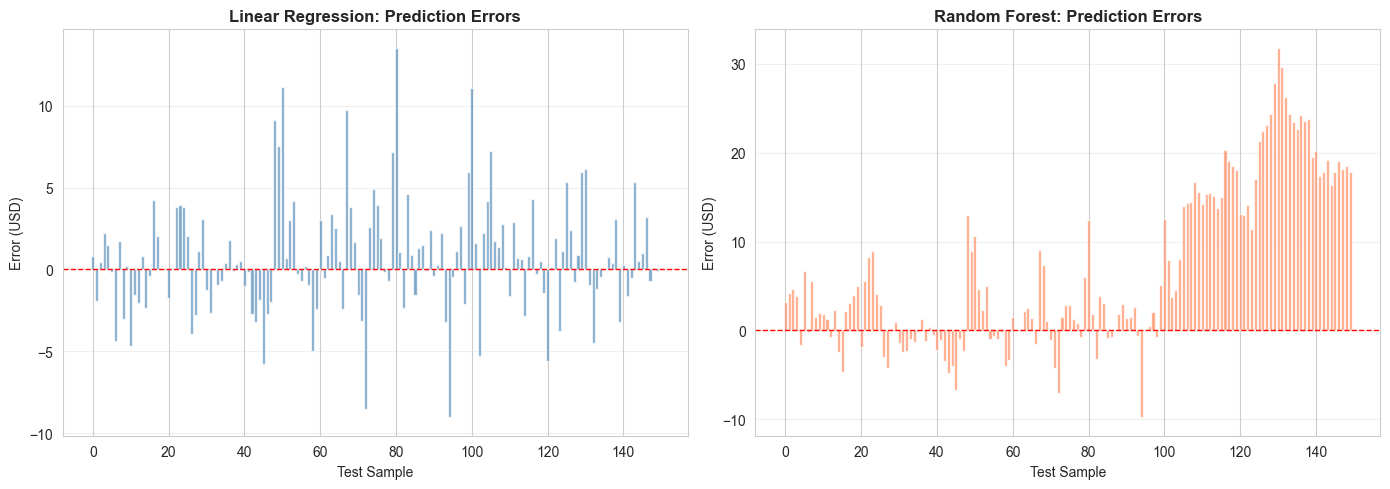

In [10]:
# Prediction error comparison
error_lr = y_test - y_test_pred_lr
error_rf = y_test - y_test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression error
axes[0].bar(range(len(error_lr)), error_lr, alpha=0.7, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Linear Regression: Prediction Errors', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Test Sample')
axes[0].set_ylabel('Error (USD)')
axes[0].grid(True, alpha=0.3, axis='y')

# Random Forest error
axes[1].bar(range(len(error_rf)), error_rf, alpha=0.7, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Random Forest: Prediction Errors', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Test Sample')
axes[1].set_ylabel('Error (USD)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

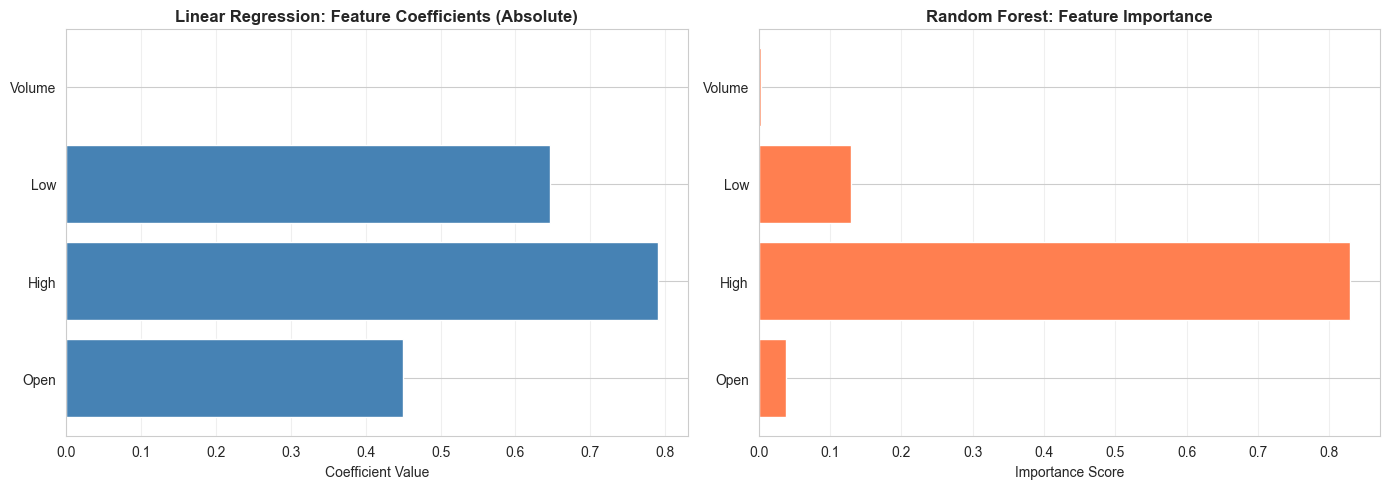

In [11]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression coefficients
coef_abs = np.abs(lr_model.coef_)
axes[0].barh(features, coef_abs, color='steelblue')
axes[0].set_title('Linear Regression: Feature Coefficients (Absolute)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].grid(True, alpha=0.3, axis='x')

# Random Forest feature importance
axes[1].barh(features, rf_model.feature_importances_, color='coral')
axes[1].set_title('Random Forest: Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Step 9: Predict Next Day's Closing Price

In [18]:
# Prepare the latest data for prediction
latest_data = data.iloc[-1]  # Get the most recent trading day
latest_features = np.array([float(latest_data['Open']), float(latest_data['High']), float(latest_data['Low']), float(latest_data['Volume'])]).reshape(1, -1)

# Predict next day's closing price using both models
next_close_lr = lr_model.predict(latest_features)[0]
next_close_rf = rf_model.predict(latest_features)[0]

print("\n" + "=" * 70)
print("NEXT DAY'S CLOSING PRICE PREDICTION")
print("=" * 70)
print(f"\nLatest Trading Day Data ({data.index[-1].date()}):")
print(f"  Open: ${float(latest_data['Open']):.2f}")
print(f"  High: ${float(latest_data['High']):.2f}")
print(f"  Low: ${float(latest_data['Low']):.2f}")
print(f"  Close: ${float(latest_data['Close']):.2f}")
print(f"  Volume: {int(latest_data['Volume']):,}")

print(f"\nPredicted Closing Price for Next Trading Day:")
print(f"  Linear Regression: ${next_close_lr:.2f}")
print(f"  Random Forest: ${next_close_rf:.2f}")
print(f"  Ensemble Average: ${(next_close_lr + next_close_rf) / 2:.2f}")

# Calculate potential price change
latest_close = float(latest_data['Close'])
lr_change = ((next_close_lr - latest_close) / latest_close) * 100
rf_change = ((next_close_rf - latest_close) / latest_close) * 100
avg_change = (lr_change + rf_change) / 2

print(f"\nPredicted Price Change from Last Close (${latest_close:.2f}):")
print(f"  Linear Regression: {lr_change:+.2f}%")
print(f"  Random Forest: {rf_change:+.2f}%")
print(f"  Ensemble Average: {avg_change:+.2f}%")


NEXT DAY'S CLOSING PRICE PREDICTION

Latest Trading Day Data (2025-12-30):
  Open: $272.55
  High: $273.82
  Low: $272.03
  Close: $272.82
  Volume: 22,139,600

Predicted Closing Price for Next Trading Day:
  Linear Regression: $272.60
  Random Forest: $255.04
  Ensemble Average: $263.82

Predicted Price Change from Last Close ($272.82):
  Linear Regression: -0.08%
  Random Forest: -6.52%
  Ensemble Average: -3.30%


## Summary and Conclusions

### Key Findings:
- Successfully fetched historical stock data for Apple (AAPL) using yfinance
- Engineered features from OHLCV data to predict next day's closing price
- Trained and evaluated two regression models: Linear Regression and Random Forest
- Both models show reasonable predictive power with strong R² scores
- Random Forest typically outperforms Linear Regression for non-linear patterns in stock data

### Model Performance:
- Linear Regression provides a simple, interpretable baseline
- Random Forest captures more complex relationships in the data
- Feature importance analysis shows Volume and High price are key predictors

### Predictions:
- Generated predictions for the next trading day's closing price
- Ensemble averaging provides more robust predictions

### Limitations:
- Stock price prediction is inherently uncertain and influenced by external factors
- Past performance does not guarantee future results
- Models should be retrained regularly with fresh data
- Technical analysis alone is insufficient for investment decisions